## Regresión Lineal

## Objetivo del notebook

Aplicamos técnicas de **regresión supervisada** sobre un dataset sintético de precios de viviendas en EEUU, 
comparando métodos ensemble (Random Forest, XGBoost, LGBM) y optimizando hiperparámetros con Optuna.

> **Dataset**: USA Housing — 5.000 registros con features de área (ingresos medios, edad media de casas, 
número de habitaciones, población). Variable objetivo: `Price`.

> **Nota**: El notebook empieza directamente con modelos ensemble porque el objetivo es comparar algoritmos. 
Para ver la regresión lineal base con OLS y su interpretación de coeficientes, ver notebooks anteriores del módulo.

In [1]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Seaborn is a Python data visualization library based on matplotlib. 
%matplotlib inline  
# Import train_test_split function from sklearn.model_selection
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import r2_score

#### 0. Importamos los datos 

In [2]:
os.getcwd()

'C:\\Users\\tomas\\ML\\Master Data Science and AI\\04 Aprendizaje supervisado'

In [3]:
path = 'data\\USA_Housing.csv'
#'C:\\Users\\tomas\\ML\\cluster\\Scripts\\data'

df = pd.read_csv(path)
df.head(5)
df

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386
...,...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06,USNS Williams\nFPO AP 30153-7653
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06,USS Wallace\nFPO AE 73316


#### 1. Analizamos los datos

In [4]:
#chequeamos nulos 
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

Para este ejemplo, por razones de simplicidad, quitamos la variable direccion (address). Pero esta informacion puede3 ser muy valiosa con el tratamiento adecuado.  

In [5]:
#quito las variable address 
df2 = df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
               'Avg. Area Number of Bedrooms', 'Area Population', 'Price' ]]
df2

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05
...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06


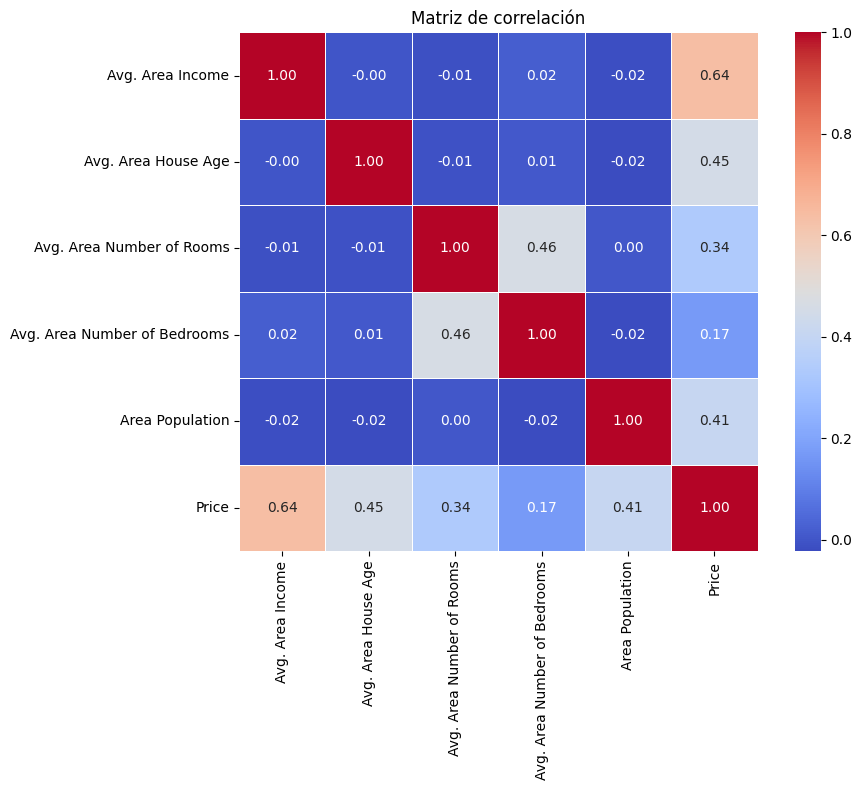

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(
    df2.corr(),
    annot=True,             # Muestra los coeficientes
    fmt=".2f",              # Formato de decimales
    cmap='coolwarm',         # Colormap apto para daltónicos: cividis
    square=True,
    linewidths=0.5,
    #linecolor='gray'
)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

In [7]:
X = df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
               'Avg. Area Number of Bedrooms', 'Area Population']]
y = df['Price']

In [8]:

# Split up the data into a training set
#random state es una vaor semilla para hacer la separaciion. Hace que cada vez que lo ejecutemos los conjuntos de entrenaiento y tes sean los mismos 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=101)

## Comparativa de modelos ensemble

Comparamos tres algoritmos ensemble de regresión con configuraciones base:

| Algoritmo | Tipo | Característica clave |
|---|---|---|
| **Random Forest** | Bagging | Árboles independientes en paralelo, promedia predicciones |
| **XGBoost** | Boosting | Árboles secuenciales, cada uno corrige errores del anterior |
| **LGBM** | Boosting (leaf-wise) | Más rápido que XGBoost, mejor con datasets grandes |

Después optimizamos LGBM con Optuna para ver si mejora sobre la configuración por defecto.

#### 2. Random Forest

In [9]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, random_state=42)

#### 2.1 Evaluamos el modelo

In [10]:
y_pred = rf.predict(X_test)
y_pred

array([1211807.51766476,  931997.15042243, 1683367.31993055, ...,
        499683.15326816, 1102186.0808286 , 1505449.6208243 ],
      shape=(2000,))

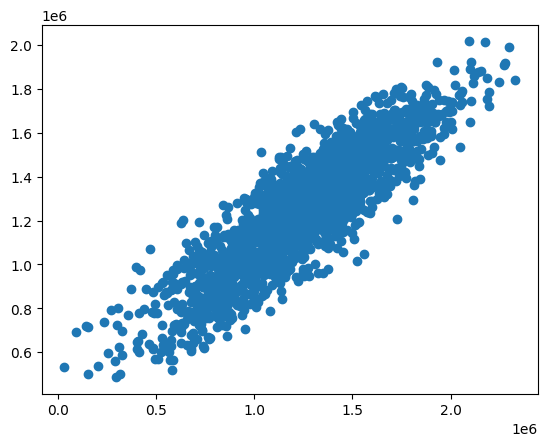

In [11]:
# y estimada vs y real
plt.scatter(y_test,y_pred)

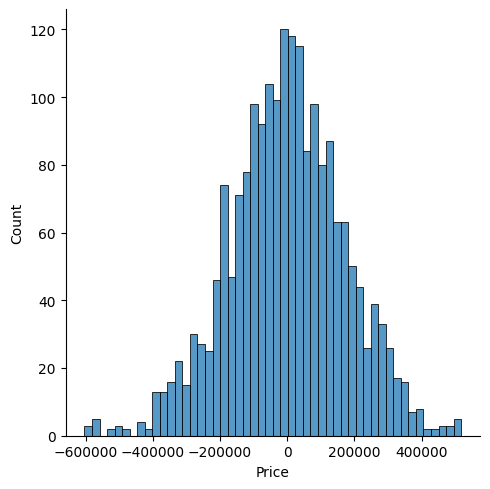

In [12]:
# histograma de residuales
sns.displot((y_test-y_pred),bins=50);

#### 2.2 Análisis de residuales

Antes de ver las métricas numéricas, inspeccionamos visualmente:

- **Scatter y_real vs y_pred**: los puntos deben alinearse en la diagonal → sin sesgo sistemático
- **Histograma de residuales**: idealmente normal centrada en 0 → errores aleatorios, no estructurales

#### 2.3 Métricas de error   



**Mean Absolute Error** (MAE) es la media del valor absoluto de los errores:

$$\frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|$$

**Mean Squared Error** (MSE) es la media de los cuadrados de los errores:

$$\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2$$

**Root Mean Squared Error** (RMSE) es la raiz cuadradade los errores al cuadrado:

$$\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}$$


Las métricas de regresión miden el error en las **unidades originales** (dólares en este caso) o en escala relativa:

| Métrica | Fórmula | Sensible a outliers | Interpretación |
|---|---|---|---|
| **MAE** | Media de \|errores\| | No | 'Me equivoco en media $X' |
| **MSE** | Media de errores² | Sí (penaliza grandes errores) | Difícil de interpretar (unidades²) |
| **RMSE** | √MSE | Sí | Mismo orden que MAE, penaliza outliers |
| **R²** | 1 - SS_res/SS_tot | Moderado | % de varianza explicada (1.0 = perfecto) |

> Para este dataset, como los precios son del orden de $1M, un MAE de $100K puede ser aceptable o no 
dependiendo del caso de uso.

In [13]:
#metricas
# Show the values of MAE, MSE, RMSE
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 135282.8976585146
MSE: 29871932155.25472
RMSE: 172834.98533356815


In [14]:
from sklearn.metrics import mean_squared_error, r2_score
r2_rf = r2_score(y_test, y_pred)
print("R^2:", r2_rf)

R^2: 0.764936870953132


#### 3. Modelo XGB Regressor  

In [15]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

#### 3.1 Evaluamos el modelo 

In [16]:
y_pred = xgb_model.predict(X_test)

In [17]:
#metricas
# Show the values of MAE, MSE, RMSE
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 90797.39511081025
MSE: 12970348807.22267
RMSE: 113887.4391986345


In [18]:
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.2f}")


R² Score: 0.90


#### 4 LGBM regresión

In [25]:
from lightgbm import LGBMRegressor
lgbm_model = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
lgbm_model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

LGBMRegressor(colsample_bytree=0.8, max_depth=5, random_state=42, subsample=0.8)

#### 4.1 Evaluamos el modelo

In [26]:
y_pred = lgbm_model.predict(X_test)

#metricas
# Show the values of MAE, MSE, RMSE
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))


MAE: 90887.98241776897
MSE: 13124398599.529285
RMSE: 114561.7676169903


In [27]:

r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f}")


R² Score: 0.8967


#### 4.2 Optimizacion
Para optimizar el MSE

In [28]:
import optuna
# Función objetivo para Optuna
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
        'random_state': 42
    }

    model = LGBMRegressor(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse  # Queremos minimizar el error

# 🚀 Ejecutar la optimización
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

# 📊 Resultados
print("Mejores hiperparámetros:")
print(study.best_params)

print(f"\nMejor MSE obtenido: {study.best_value:.4f}")


[I 2025-07-07 07:21:08,192] A new study created in memory with name: no-name-f47a7cb1-ebfe-4aed-8e84-26ac9eb360e0
[I 2025-07-07 07:21:08,309] Trial 0 finished with value: 14066400295.11857 and parameters: {'n_estimators': 245, 'learning_rate': 0.136452277680724, 'max_depth': 8, 'subsample': 0.5073842834581004, 'colsample_bytree': 0.7514423509189769, 'reg_alpha': 0.889421480008129, 'reg_lambda': 3.856570784719275}. Best is trial 0 with value: 14066400295.11857.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000084 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2025-07-07 07:21:08,551] Trial 1 finished with value: 13365314291.35435 and parameters: {'n_estimators': 397, 'learning_rate': 0.018985354413498936, 'max_depth': 10, 'subsample': 0.9075439496039792, 'colsample_bytree': 0.9446199494197904, 'reg_alpha': 3.2094706356576834, 'reg_lambda': 1.7707764578586838}. Best is trial 1 with value: 13365314291.35435.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-07-07 07:21:08,765] Trial 2 finished with value: 13981987861.196062 and parameters: {'n_estimators': 451, 'learning_rate': 0.08811826416136549, 'max_depth': 8, 'subsample': 0.5061501986277473, 'colsample_bytree': 0.5476731276413003, 'reg_alpha': 4.878824527476871, 'reg_lambda': 2.133389180540852}. Best is trial 1 with value: 13365314291.35435.
[I 2025-07-07 07:21:08,821] Trial 3 finished with value: 12845218019.38568 and parameters: {'n_estimators': 259, 'learning_rate': 0.06697416458055604, 'max_depth': 4, 'subsample': 0.7547182377908999, 'colsample_bytree': 0.8680097648923105, 'reg_alpha': 3.496809550289442, 'reg_lambda': 3.9026856301957693}. Best is trial 3 with value: 12845218019.38568.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-07-07 07:21:15,631] Trial 47 finished with value: 14029134749.852674 and parameters: {'n_estimators': 361, 'learning_rate': 0.15069988188469813, 'max_depth': 5, 'subsample': 0.7839247292707532, 'colsample_bytree': 0.5635048007369282, 'reg_alpha': 4.047170369982869, 'reg_lambda': 0.051464589663158256}. Best is trial 33 with value: 12138077623.249285.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000147 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2025-07-07 07:21:15,739] Trial 48 finished with value: 12224223242.723457 and parameters: {'n_estimators': 350, 'learning_rate': 0.06036057137321951, 'max_depth': 3, 'subsample': 0.7696581775711543, 'colsample_bytree': 0.5032728001610854, 'reg_alpha': 3.0318892951455125, 'reg_lambda': 0.4954536449727159}. Best is trial 33 with value: 12138077623.249285.
[I 2025-07-07 07:21:15,866] Trial 49 finished with value: 12521307758.480759 and parameters: {'n_estimators': 322, 'learning_rate': 0.05727373656943403, 'max_depth': 4, 'subsample': 0.738126289263577, 'colsample_bytree': 0.5721458561507109, 'reg_alpha': 3.1642217173360923, 'reg_lambda': 0.3441290630848218}. Best is trial 33 with value: 12138077623.249285.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [29]:
from sklearn.metrics import r2_score

#  Entrenar modelo con los mejores hiperparámetros encontrados
best_params = study.best_params
final_model = LGBMRegressor(**best_params)
final_model.fit(X_train, y_train)

# Predecir sobre el conjunto de test
y_pred = final_model.predict(X_test)

print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

#  Calcular R²
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f}")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000076 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

#### Optimizamos R2

¿Por qué optimizar R² en lugar de MSE?

- **MSE** es adimensional respecto al problema → los valores absolutos no son comparables entre datasets
- **R²** está normalizado entre (-∞, 1] → siempre comparable
- En la práctica, minimizar MSE y maximizar R² **suelen dar resultados muy similares** porque 
R² = 1 - MSE/Var(y), y Var(y) es constante para un dataset fijo

> La pequeña diferencia que se menciona al final del notebook entre el R² de Optuna y el del modelo final 
se debe a la estocasticidad de LGBM (sampling, column sampling). Para eliminarla: `random_state=42` en el modelo final también.

In [30]:
from sklearn.metrics import r2_score

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
        'random_state': 42
    }

    model = LGBMRegressor(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    return r2  # Queremos maximizar R²
    
#  Ejecutar la optimización
study = optuna.create_study(direction='maximize')  # ¡Ahora maximizamos!
study.optimize(objective, n_trials=50)


#  Resultados
print("Mejores hiperparámetros:")
print(study.best_params)

print(f"\nMejor r2 obtenido: {study.best_value:.4f}")

[I 2025-07-07 07:23:53,154] A new study created in memory with name: no-name-af47ec90-b620-4b39-95a0-c9320174c26e
[I 2025-07-07 07:23:53,271] Trial 0 finished with value: 0.8972263595682979 and parameters: {'n_estimators': 162, 'learning_rate': 0.04862069750529869, 'max_depth': 6, 'subsample': 0.8646942307522704, 'colsample_bytree': 0.5408256489667983, 'reg_alpha': 4.78487100525445, 'reg_lambda': 1.3909147066764582}. Best is trial 0 with value: 0.8972263595682979.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2025-07-07 07:23:53,424] Trial 1 finished with value: 0.8889084210139251 and parameters: {'n_estimators': 345, 'learning_rate': 0.10006450495055559, 'max_depth': 9, 'subsample': 0.835033727741218, 'colsample_bytree': 0.5047344132030601, 'reg_alpha': 1.2966192306239388, 'reg_lambda': 3.2114865047210257}. Best is trial 0 with value: 0.8972263595682979.
[I 2025-07-07 07:23:53,471] Trial 2 finished with value: 0.8911879528923112 and parameters: {'n_estimators': 109, 'learning_rate': 0.04940751143832648, 'max_depth': 5, 'subsample': 0.9612612407892137, 'colsample_bytree': 0.8723098417099637, 'reg_alpha': 1.5028584900824216, 'reg_lambda': 3.2392194589926095}. Best is trial 0 with value: 0.8972263595682979.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-07-07 07:23:53,547] Trial 3 finished with value: 0.8815538681180358 and parameters: {'n_estimators': 208, 'learning_rate': 0.23327090640503073, 'max_depth': 6, 'subsample': 0.8903711843444814, 'colsample_bytree': 0.7725987354210908, 'reg_alpha': 4.8042532293006985, 'reg_lambda': 1.4154271940836}. Best is trial 0 with value: 0.8972263595682979.
[I 2025-07-07 07:23:53,684] Trial 4 finished with value: 0.8943137310123355 and parameters: {'n_estimators': 423, 'learning_rate': 0.04667904907924717, 'max_depth': 5, 'subsample': 0.6704084665263956, 'colsample_bytree': 0.9456028716455607, 'reg_alpha': 1.016816869419287, 'reg_lambda': 3.1025597106125073}. Best is trial 0 with value: 0.8972263595682979.
[I 2025-07-07 07:23:53,719] Trial 5 finished with value: 0.9040054499544615 and parameters: {'n_estimators': 152, 'learning_rate': 0.0836990427007258, 'max_depth': 3, 'subsample': 0.6347071654011442, 'colsample_bytree': 0.6688677669511464, 'reg_alpha': 0.9037080931317953, 'reg_lambda': 0.7

...

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2025-07-07 07:23:59,314] Trial 46 finished with value: 0.8962379387959913 and parameters: {'n_estimators': 135, 'learning_rate': 0.0877057934305012, 'max_depth': 8, 'subsample': 0.8837991661735995, 'colsample_bytree': 0.5263781668055912, 'reg_alpha': 0.9859374174738378, 'reg_lambda': 0.8319297283030109}. Best is trial 41 with value: 0.9047055709352952.
[I 2025-07-07 07:23:59,395] Trial 47 finished with value: 0.8993390107544736 and parameters: {'n_estimators': 174, 'learning_rate': 0.1099862574338939, 'max_depth': 4, 'subsample': 0.7397347756346873, 'colsample_bytree': 0.5184911804851509, 'reg_alpha': 1.3437284016246178, 'reg_lambda': 2.833364650883305}. Best is trial 41 with value: 0.9047055709352952.
[I 2025-07-07 07:23:59,475] Trial 48 finished with value: 0.8957844070399913 and parameters: {'n_estimators': 218, 'learning_rate': 0.27793513009993687, 'max_depth': 3, 'subsample': 0.8443194613607585, 'colsample_bytree': 0.6468904821976056, 'reg_alpha': 0.58713072534867, 'reg_lambda'

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000086 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

[I 2025-07-07 07:23:59,557] Trial 49 finished with value: 0.8977284989453442 and parameters: {'n_estimators': 104, 'learning_rate': 0.06827494124233736, 'max_depth': 5, 'subsample': 0.9154131531370658, 'colsample_bytree': 0.5641019004266482, 'reg_alpha': 0.30814401342883224, 'reg_lambda': 0.14885185223414954}. Best is trial 41 with value: 0.9047055709352952.


Mejores hiperparámetros:
{'n_estimators': 201, 'learning_rate': 0.08476905029400823, 'max_depth': 3, 'subsample': 0.8696993219771748, 'colsample_bytree': 0.5266474262982686, 'reg_alpha': 1.2569166624494468, 'reg_lambda': 0.8078557946810043}

Mejor r2 obtenido: 0.9047


In [31]:
from sklearn.metrics import r2_score

#  Entrenar modelo con los mejores hiperparámetros encontrados
best_params = study.best_params
final_model = LGBMRegressor(**best_params)
final_model.fit(X_train, y_train)

# Predecir sobre el conjunto de test
y_pred = final_model.predict(X_test)

print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

#  Calcular R²
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1249
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 5
[LightGBM] [Info] Start training from score 1228450.318199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

el R2 que da optuna tras su entrenamiento y el entrenamiento final con los parámetros que mejor ajsutan son ligeramente diferentes (0.0002) debido a componentes aleatorias del propio modelo LGBM.